<a href="https://colab.research.google.com/github/vanashreenarvekar-hub/Deep-Learning-using-Keras/blob/main/task7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim

To implement Autoencoder and Variational Autoencoder models for learning compact image representations, reconstructing images, and analyzing latent space representations.

In [1]:
# Task 7: Autoencoders and Variational Autoencoders

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.21.0
Libraries imported successfully!


Dataset

The MNIST dataset contains 70,000 grayscale images of handwritten digits from 0 to 9. It consists of 60,000 training images and 10,000 test images, each of size 28 × 28 pixels. Pixel values are normalized to the range 0–1, and each image is flattened into 784 features for training.

Theory

An Autoencoder is an unsupervised neural network that learns a compressed representation of its input. It consists of an encoder, which maps the input to a lower-dimensional latent representation, and a decoder, which reconstructs the original input from that representation.
A Variational Autoencoder (VAE) is a generative model that learns a probability distribution over latent representations. It uses a mean vector and a log-variance vector to represent the latent distribution. The reparameterization trick allows sampling while maintaining differentiability. Its objective combines reconstruction loss and KL divergence.

In [2]:
# Load the MNIST dataset

from tensorflow.keras.datasets import mnist

(x_train, _), (x_test, _) = mnist.load_data()

print("Dataset loaded successfully!")
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [3]:
# Normalize and flatten images

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (60000, 784)
Testing shape: (10000, 784)


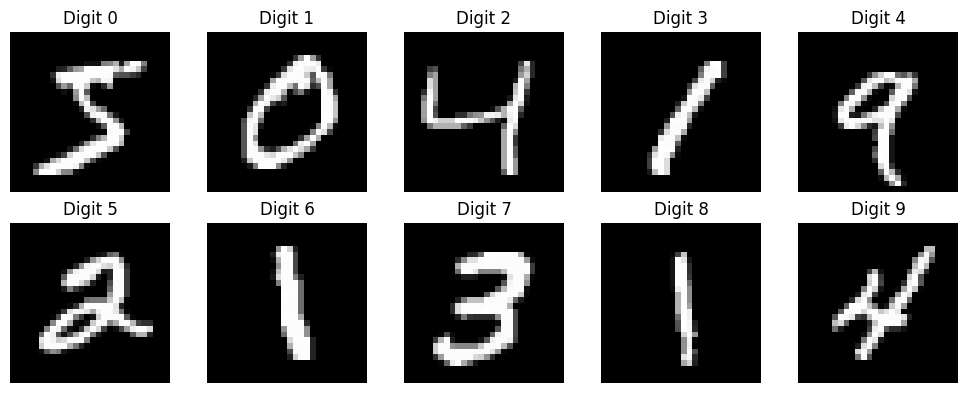

In [4]:
# Display sample MNIST images

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Digit {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

An Autoencoder has two main parts:
- Encoder: Compresses the input into a smaller latent representation.
- Decoder: Reconstructs the image from that compressed representation.

In [5]:
# Build the Autoencoder

from tensorflow.keras import layers, Model

input_img = layers.Input(shape=(784,))

# Encoder
encoded = layers.Dense(128, activation="relu")(input_img)
latent = layers.Dense(32, activation="relu", name="latent_space")(encoded)

# Decoder
decoded = layers.Dense(128, activation="relu")(latent)
output_img = layers.Dense(784, activation="sigmoid")(decoded)

autoencoder = Model(input_img, output_img)

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the Autoencoder

autoencoder_history = autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test),
    verbose=1
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.2272 - val_loss: 0.1509
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.1346 - val_loss: 0.1209
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1157 - val_loss: 0.1084
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1070 - val_loss: 0.1029
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1024 - val_loss: 0.0998


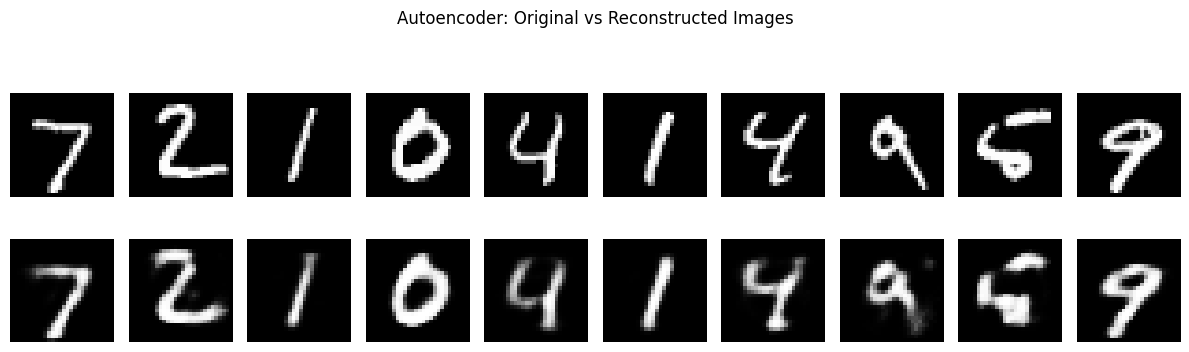

In [7]:
# Generate reconstructed images

ae_reconstructed = autoencoder.predict(x_test[:10], verbose=0)

plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original")

    plt.subplot(2, 10, i + 11)
    plt.imshow(ae_reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Reconstructed")

plt.suptitle("Autoencoder: Original vs Reconstructed Images")
plt.tight_layout()
plt.show()

In [8]:
# Build the VAE encoder

latent_dim = 32

vae_input = layers.Input(shape=(784,))
h = layers.Dense(128, activation="relu")(vae_input)

z_mean = layers.Dense(latent_dim, name="z_mean")(h)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)


def sampling(args):
    mean, log_var = args
    epsilon = tf.random.normal(shape=tf.shape(mean))
    return mean + tf.exp(0.5 * log_var) * epsilon


z = layers.Lambda(sampling, name="sampling")([z_mean, z_log_var])

vae_encoder = Model(
    vae_input,
    [z_mean, z_log_var, z],
    name="vae_encoder"
)

vae_encoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │    100,480 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      4,128 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      4,128 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Lambda)   │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 108,736 (424.75 KB)

 Trainable params: 108,736 (424.75 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Build the VAE decoder

decoder_input = layers.Input(shape=(latent_dim,))
d = layers.Dense(128, activation="relu")(decoder_input)
decoder_output = layers.Dense(784, activation="sigmoid")(d)

vae_decoder = Model(
    decoder_input,
    decoder_output,
    name="vae_decoder"
)

vae_decoder.summary()

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,360 (411.56 KB)

 Trainable params: 105,360 (411.56 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Corrected VAE model

class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_tracker,
            self.kl_tracker
        ]

    def call(self, inputs, training=False):
        mean, log_var, z = self.encoder(inputs, training=training)
        return self.decoder(z, training=training)

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            mean, log_var, z = self.encoder(data, training=True)
            reconstruction = self.decoder(z, training=True)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data, reconstruction
                    ),
                    axis=-1
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + log_var - tf.square(mean) - tf.exp(log_var),
                    axis=-1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        gradients = tape.gradient(
            total_loss, self.trainable_weights
        )

        self.optimizer.apply_gradients(
            (g, v) for g, v in zip(
                gradients, self.trainable_weights
            ) if g is not None
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_tracker.update_state(reconstruction_loss)
        self.kl_tracker.update_state(kl_loss)

        return {
            metric.name: metric.result()
            for metric in self.metrics
        }


# Create and train the corrected VAE
vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer="adam")

vae_history = vae.fit(
    x_train,
    epochs=5,
    batch_size=256,
    verbose=1
)

print("VAE training completed successfully!")

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - kl_loss: 6.3259 - loss: 58.4161 - reconstruction_loss: 52.0902
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 7.8121 - loss: 54.3442 - reconstruction_loss: 46.5321
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - kl_loss: 8.7247 - loss: 52.1236 - reconstruction_loss: 43.3988
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - kl_loss: 9.2649 - loss: 50.7302 - reconstruction_loss: 41.4653
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - kl_loss: 9.5776 - loss: 49.7564 - reconstruction_loss: 40.1788
VAE training completed successfully!


In [12]:
# Calculate reconstruction errors

ae_test_recon = autoencoder.predict(x_test, batch_size=256, verbose=0)

_, _, z_all = vae_encoder.predict(x_test, batch_size=256, verbose=0)
vae_test_recon = vae_decoder.predict(z_all, batch_size=256, verbose=0)

ae_mse = float(np.mean((x_test - ae_test_recon) ** 2))
vae_mse = float(np.mean((x_test - vae_test_recon) ** 2))

comparison = pd.DataFrame([
    {
        "Model": "Autoencoder",
        "Latent Dimensions": 32,
        "Reconstruction MSE": ae_mse
    },
    {
        "Model": "Variational Autoencoder",
        "Latent Dimensions": 32,
        "Reconstruction MSE": vae_mse
    }
])

comparison["Reconstruction MSE"] = comparison[
    "Reconstruction MSE"
].round(6)

display(comparison)

,Model,Latent Dimensions,Reconstruction MSE
0,Autoencoder,32,0.012316
1,Variational Autoencoder,32,0.030865


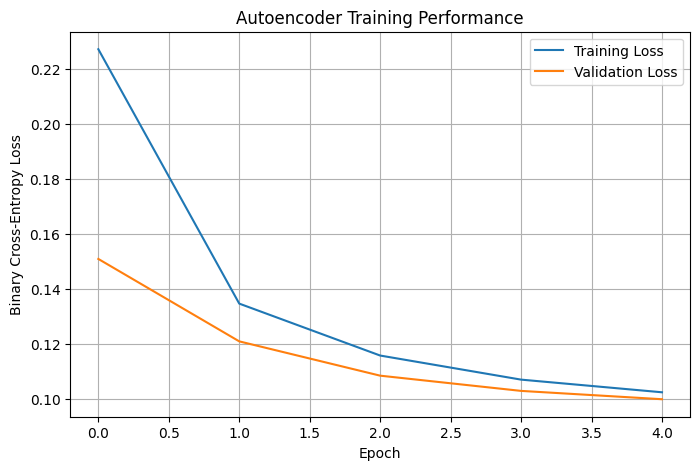

In [13]:
# Plot Autoencoder training and validation loss

plt.figure(figsize=(8, 5))
plt.plot(
    autoencoder_history.history["loss"],
    label="Training Loss"
)
plt.plot(
    autoencoder_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Autoencoder Training Performance")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()

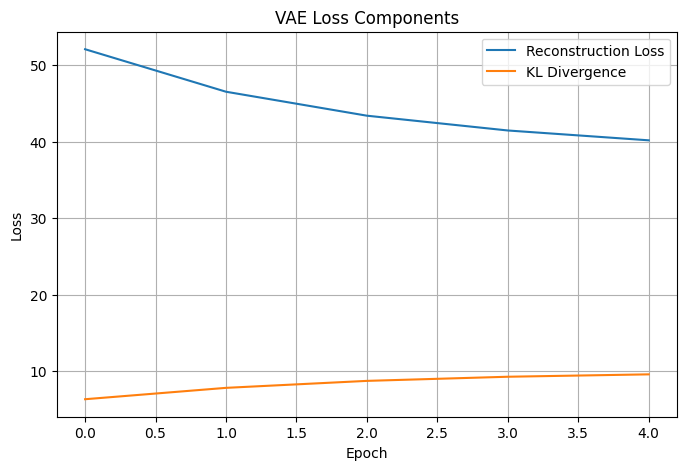

In [14]:
# Plot VAE training loss components

plt.figure(figsize=(8, 5))

plt.plot(
    vae_history.history["reconstruction_loss"],
    label="Reconstruction Loss"
)
plt.plot(
    vae_history.history["kl_loss"],
    label="KL Divergence"
)

plt.title("VAE Loss Components")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

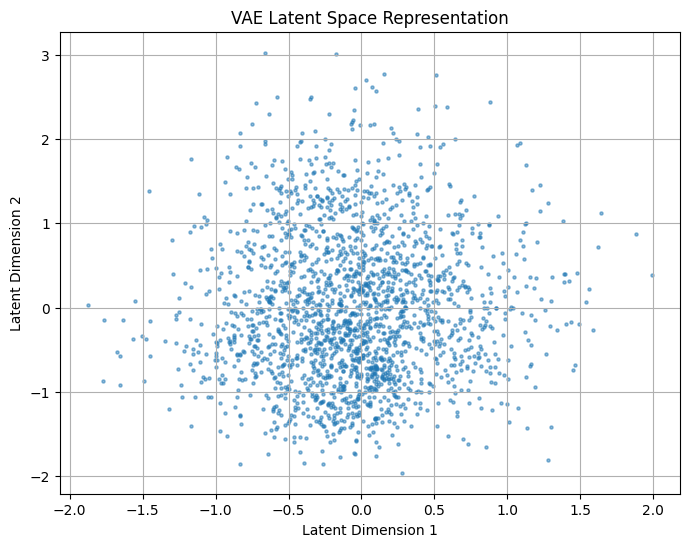

In [15]:
# Visualize the first two dimensions of the VAE latent space

z_mean_test, _, _ = vae_encoder.predict(
    x_test[:2000],
    batch_size=256,
    verbose=0
)

plt.figure(figsize=(8, 6))
plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    s=5,
    alpha=0.5
)

plt.title("VAE Latent Space Representation")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True)
plt.show()

Result

The Autoencoder and Variational Autoencoder architectures were implemented using the MNIST dataset. Both models learned compressed representations and generated reconstructed images. Their reconstruction quality was compared using mean squared error, while training-loss graphs and latent-space visualization were used to analyze their learning behavior.


Conclusion

This assignment demonstrated representation learning through Autoencoders and Variational Autoencoders. The Autoencoder learned a compact representation for image reconstruction, whereas the VAE learned a structured probabilistic latent space. Comparing reconstruction errors and visual outputs helped illustrate the trade-offs between reconstruction quality and generative representation learning.